In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config_v5.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 25  |  Patience: 6
Use Focal   : True  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.1507     0.5264    0.5240    0.5915    0.5844    LR: 1.00e-03


2      0.1171     0.6984    0.6791    0.6597    0.6444    LR: 1.00e-03


3      0.0864     0.8043    0.7783    0.7485    0.7156    LR: 1.00e-03


4      0.0541     0.8881    0.8648    0.7957    0.7458    LR: 1.00e-03


...

12     0.0022     0.9968    0.9956    0.8097    0.7499    LR: 5.00e-04


13     0.0026     0.9959    0.9945    0.8135    0.7449    LR: 2.50e-04


14     0.0021     0.9967    0.9955    0.7900    0.7353    LR: 2.50e-04


15     0.0008     0.9989    0.9986    0.8133    0.7508    LR: 2.50e-04


16     0.0005     0.9994    0.9992    0.8057    0.7440    LR: 1.25e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.88      0.86      0.87      3030
      Sexist       0.59      0.65      0.62       970

    accuracy                           0.81      4000
   macro avg       0.74      0.75      0.74      4000
weighted avg       0.81      0.81      0.81      4000

Accuracy : 0.8057
Macro F1 : 0.7440
Weighted F1 : 0.8087

Confusion Matrix (raw):
[[2594  436]
 [ 341  629]]


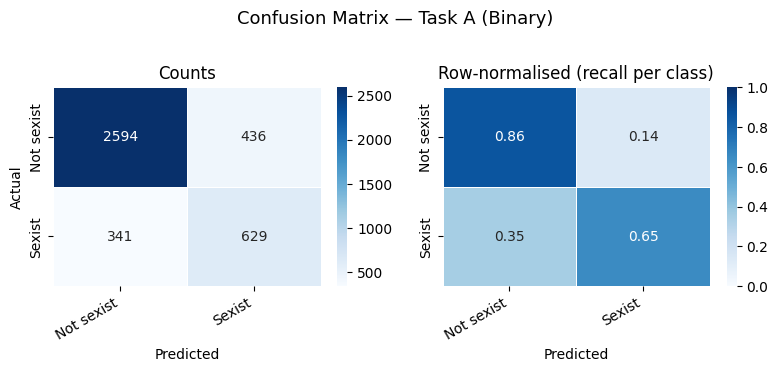

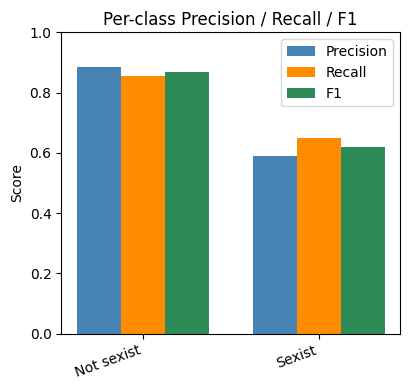


ERROR ANALYSIS

Total errors: 777 / 4000 (19.4%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,341,970,35.2
0,Not sexist,436,3030,14.4



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,436
1,Sexist,Not sexist,341


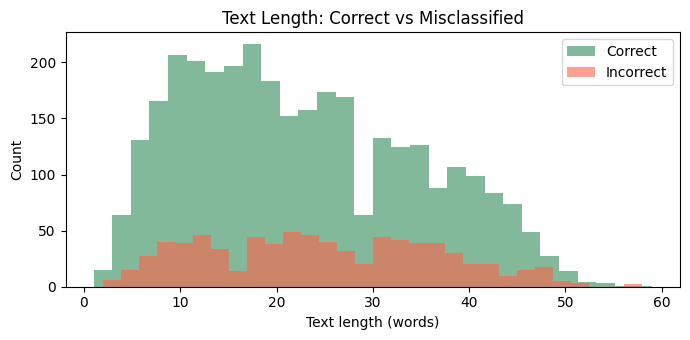


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 436)
    • (0.96) lol, a canadian guy legally changed his gender to female so that he would save $100 a year on car insurance. a female la
    • (0.93) i have some unwashed underwear she can sniff i am not sure if it is sarin but i am positive it is toxic and probably wmd
    • (0.90) if your daughter is socializing with blacks, and visiting black areas, and partying around blacks - then the fact she ha

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 341)
    • (0.79) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.97) i would pay to see her ass cracker. #nsfw
    • (0.66) if you don't want your mother fucked, keep her off the streets

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [3]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.7582     0.1828    0.1823    0.2412    0.2390    LR: 1.00e-03


2      0.5224     0.3888    0.3879    0.3856    0.3733    LR: 1.00e-03


3      0.3591     0.4727    0.5012    0.4361    0.4290    LR: 1.00e-03


4      0.2490     0.5350    0.5883    0.4010    0.3770    LR: 1.00e-03


...

12     0.0233     0.8800    0.9247    0.5227    0.4957    LR: 5.00e-04


13     0.0157     0.9274    0.9541    0.5309    0.5030    LR: 2.50e-04


14     0.0105     0.9575    0.9729    0.5278    0.4880    LR: 2.50e-04


15     0.0071     0.9725    0.9824    0.5258    0.4870    LR: 2.50e-04


16     0.0059     0.9779    0.9858    0.5278    0.4857    LR: 1.25e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.51      0.44      0.47        89
           Derogation       0.58      0.52      0.55       454
            Animosity       0.50      0.61      0.55       333
Prejudiced Discussion       0.43      0.33      0.37        94

             accuracy                           0.53       970
            macro avg       0.50      0.48      0.49       970
         weighted avg       0.53      0.53      0.53       970

Accuracy : 0.5278
Macro F1 : 0.4857
Weighted F1 : 0.5254

Confusion Matrix (raw):
[[ 39  29  17   4]
 [ 18 238 172  26]
 [ 11 107 204  11]
 [  9  37  17  31]]


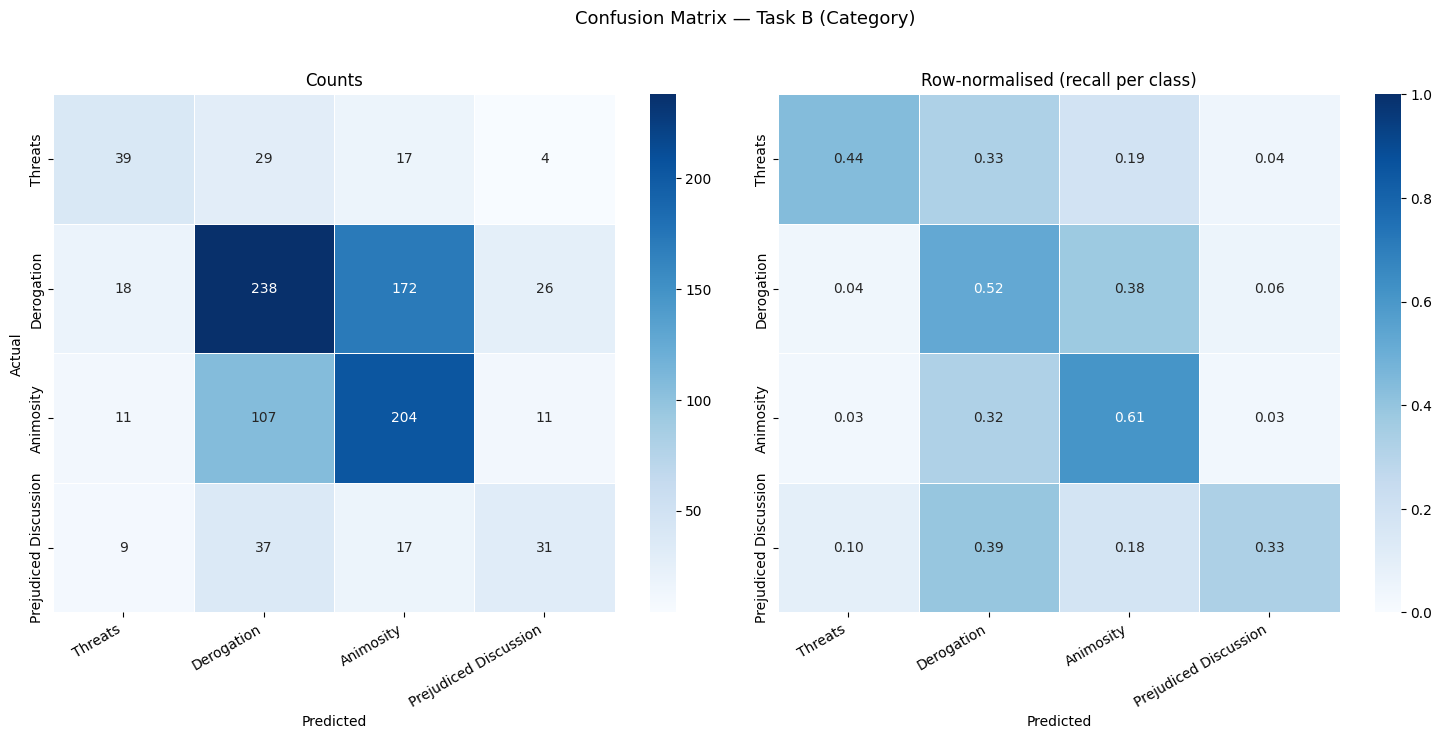

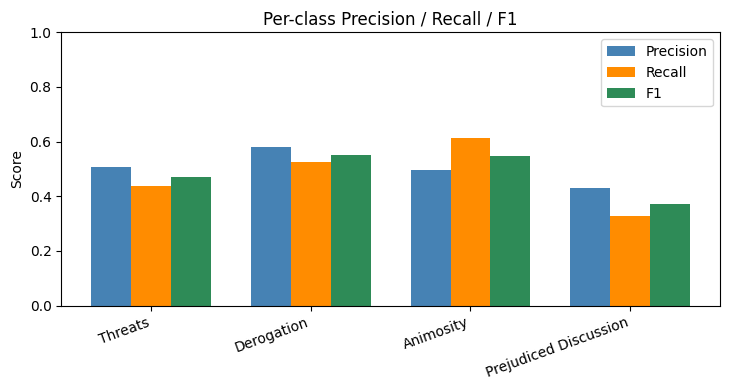


ERROR ANALYSIS

Total errors: 458 / 970 (47.2%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,63,94,67.0
0,Threats,50,89,56.2
1,Derogation,216,454,47.6
2,Animosity,129,333,38.7



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,172
0,Animosity,Derogation,107
7,Prejudiced Discussion,Derogation,37
10,Threats,Derogation,29
4,Derogation,Prejudiced Discussion,26
5,Derogation,Threats,18
6,Prejudiced Discussion,Animosity,17
9,Threats,Animosity,17
2,Animosity,Threats,11
1,Animosity,Prejudiced Discussion,11


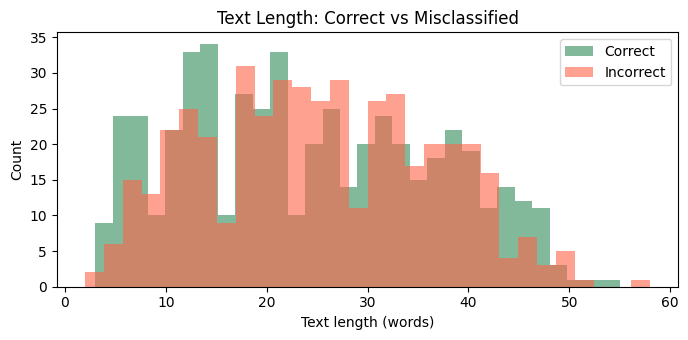


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 172)
    • (0.88) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.55) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (0.83) if you don't want your mother fucked, keep her off the streets

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 107)
    • (0.64) most here would fuck her.
    • (0.51) #feminist looks to have sex with #nazis on #tinder. she even is a vegetarian, and an artist just like #hitler was! does 
    • (0.58) lol being an ugly dyke and an annoying jew are plenty enough reason to find her unwatchable.

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 37)
    • (0.61) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l
    • (0

In [4]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

5      0.0582     0.9492    0.9329    0.8555    0.8143    LR: 1.78e-05


6      0.0419     0.9713    0.9615    0.8738    0.8209    LR: 1.69e-05


7      0.0306     0.9808    0.9741    0.8770    0.8268    LR: 1.60e-05


8      0.0247     0.9855    0.9804    0.8630    0.8152    LR: 1.51e-05


9      0.0226     0.9871    0.9826    0.8708    0.8257    LR: 1.42e-05

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.92      0.91      0.91      3030
      Sexist       0.73      0.75      0.74       970

    accuracy                           0.87      4000
   macro avg       0.82      0.83      0.83      4000
weighted avg       0.87      0.87      0.87      4000

Accuracy : 0.8708
Macro F1 : 0.8257
Weighted F1 : 0.8713

Confusion Matrix (raw):
[[2758  272]
 [ 245  725]]


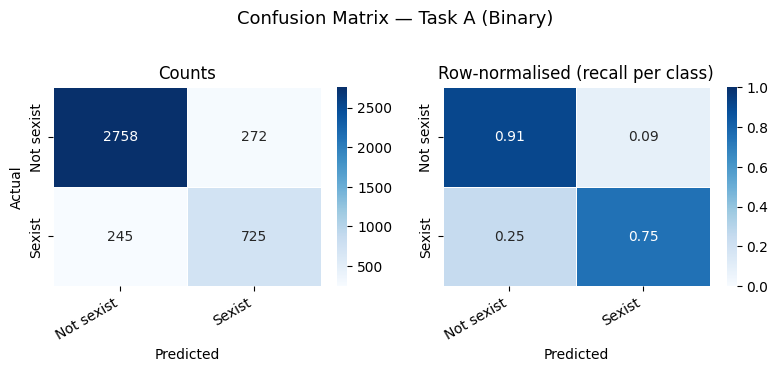

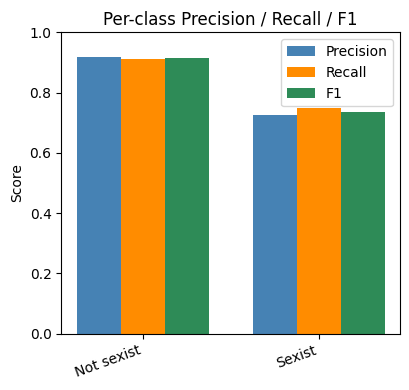


ERROR ANALYSIS

Total errors: 517 / 4000 (12.9%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,245,970,25.3
0,Not sexist,272,3030,9.0



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,272
1,Sexist,Not sexist,245


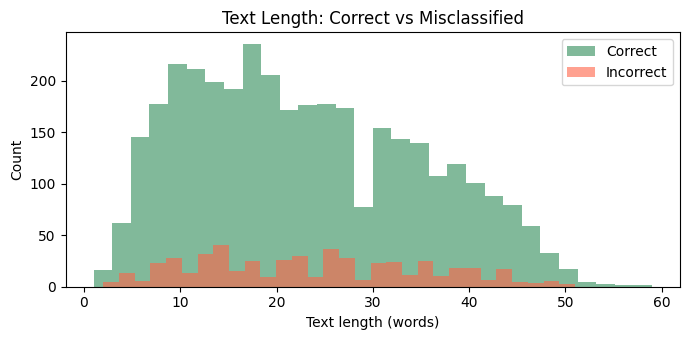


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 272)
    • (0.93) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (0.91) true, most do lol i get hit on by more fat girls than anything else. but they usually settle for an out of shape guy. fi
    • (0.98) welcome to gender equality. suck it!

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 245)
    • (0.97) i would pay to see her ass cracker. #nsfw
    • (0.98) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.98) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [5]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.8862     0.2667    0.2198    0.2866    0.2760    LR: 8.01e-06


...

13     0.0063     0.9825    0.9870    0.6206    0.5936    LR: 1.07e-05


14     0.0031     0.9902    0.9928    0.6392    0.6264    LR: 9.78e-06


15     0.0027     0.9928    0.9947    0.6258    0.6205    LR: 8.89e-06


16     0.0049     0.9910    0.9931    0.6330    0.6248    LR: 8.00e-06


17     0.0032     0.9946    0.9956    0.6299    0.6204    LR: 7.11e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.69      0.69      0.69        89
           Derogation       0.63      0.76      0.69       454
            Animosity       0.63      0.45      0.53       333
Prejudiced Discussion       0.57      0.60      0.58        94

             accuracy                           0.63       970
            macro avg       0.63      0.62      0.62       970
         weighted avg       0.63      0.63      0.62       970

Accuracy : 0.6299
Macro F1 : 0.6204
Weighted F1 : 0.6224

Confusion Matrix (raw):
[[ 61  18   6   4]
 [ 14 343  75  22]
 [ 11 154 151  17]
 [  3  28   7  56]]


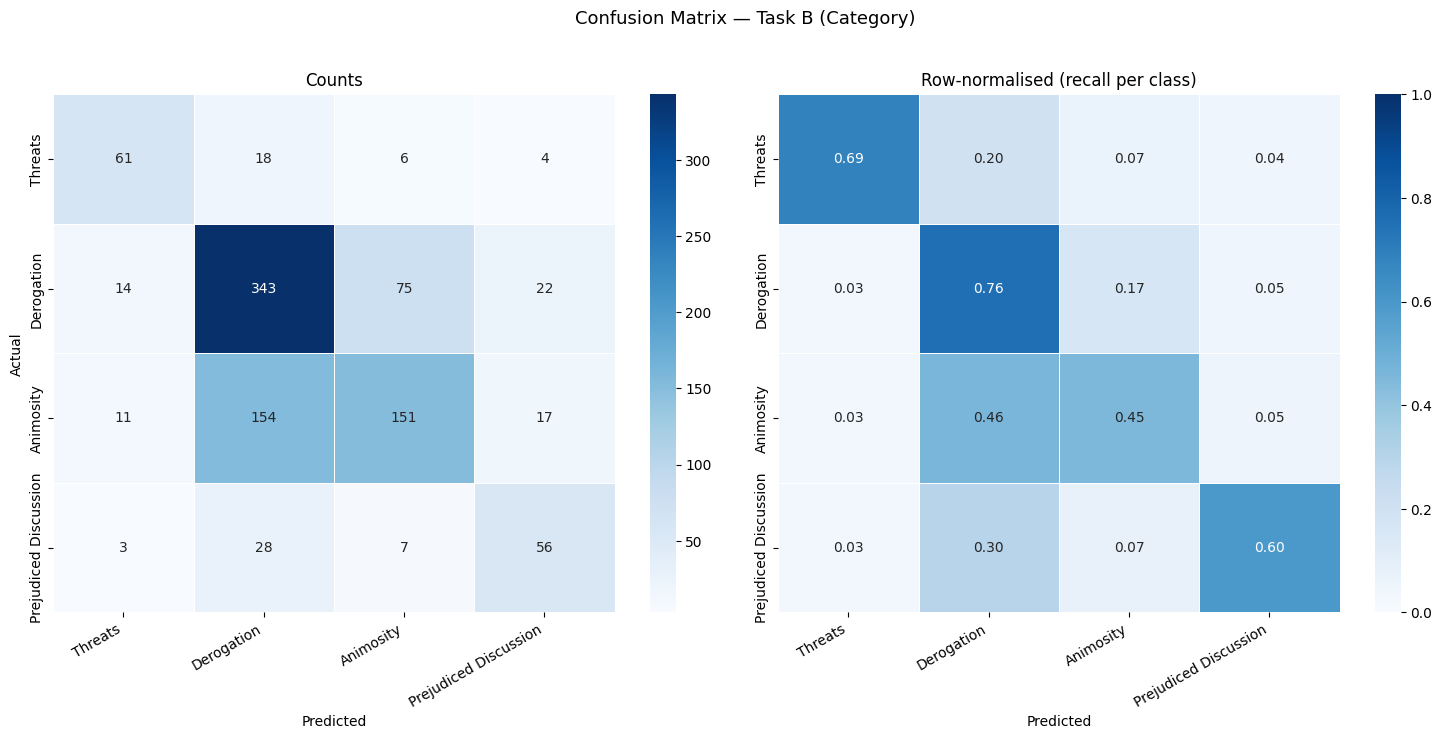

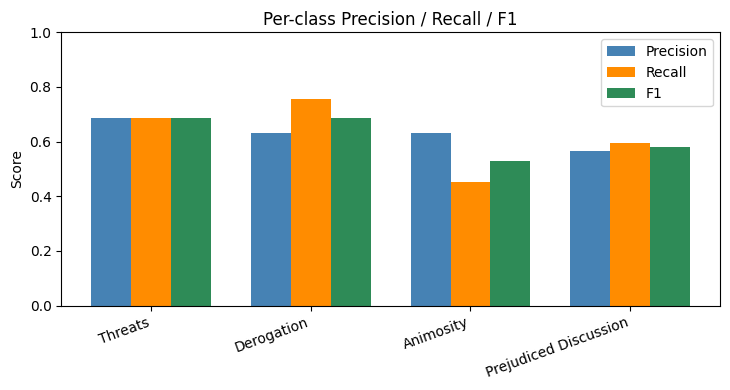


ERROR ANALYSIS

Total errors: 359 / 970 (37.0%)

Error rate per true class:


,class,errors,total,error_rate (%)
2,Animosity,182,333,54.7
3,Prejudiced Discussion,38,94,40.4
0,Threats,28,89,31.5
1,Derogation,111,454,24.4



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,154
3,Derogation,Animosity,75
7,Prejudiced Discussion,Derogation,28
4,Derogation,Prejudiced Discussion,22
10,Threats,Derogation,18
1,Animosity,Prejudiced Discussion,17
5,Derogation,Threats,14
2,Animosity,Threats,11
6,Prejudiced Discussion,Animosity,7
9,Threats,Animosity,6


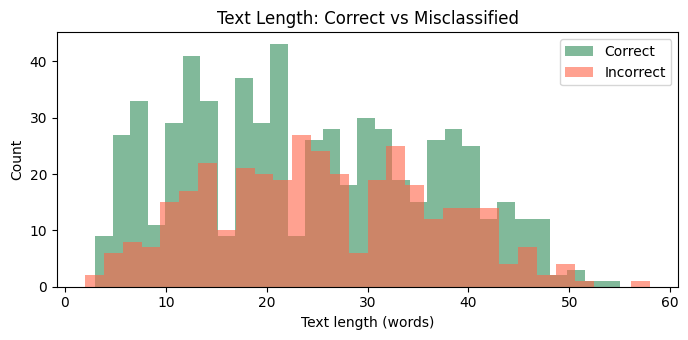


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 154)
    • (0.90) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (0.99) most here would fuck her.
    • (0.96) soy boys pms worse than women cause it's 24/7. they get their delicate feelings hurt because of lack of testosterone.it'

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 75)
    • (0.59) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.71) some, a very few men get a free and easy lay. if you are not sexually attractive, you don't get to be a horsie on the co
    • (0.97) omg you think i can slay asian pussy i already have 5 asian girlfriends but i need 10 to not be considered an incel. i’m

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 28)
    • (0.98) yes, it is new. what remains constant is that feminists are playing to the fears of w

In [6]:
tf_category = run_transformer_category(state, device)